Ta koda je namenjena racunanju in predstavitvi korelacije med izbranimi tickerji. Ugotovitve nam lahko pomagajo pri izbiranju pravih investicij za diverzificeran portfolij.

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Importa vse potrebne knjiznice

In [23]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "CLFD", "NVDA"]

Izbrani tickerji

In [24]:
start_date = "2024-01-01"
end_date = "2026-06-15"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

[*********************100%***********************]  6 of 6 completed


Povlece potrebne podatke o izbranih tickerjih

In [25]:
log_returns = np.log(data / data.shift(1)).dropna()

corr_matrix = log_returns.corr()

Izracuna, glede na podatke, ter ustvari matriko

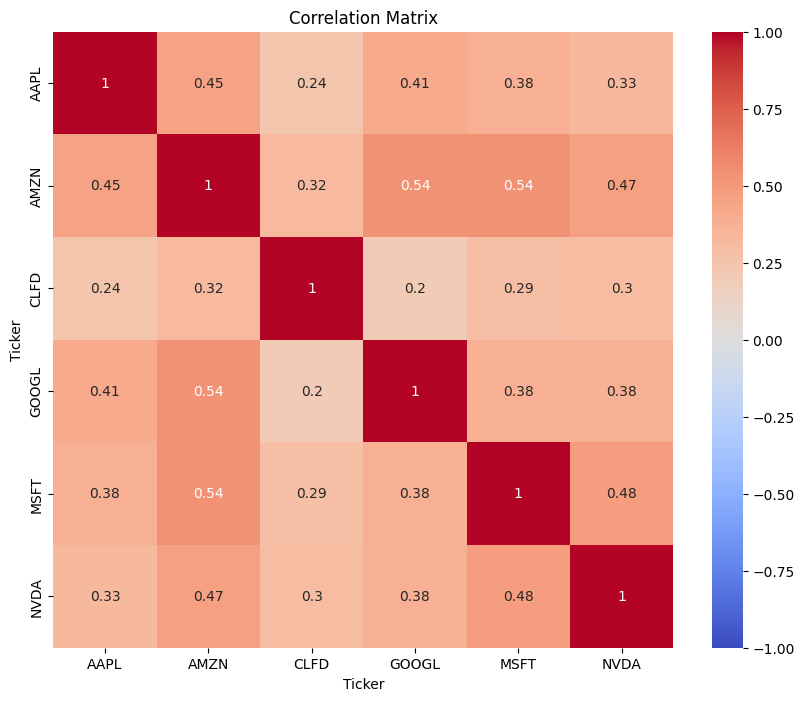

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

Vizualizacija korelacij v izbranem casovnem obdobju

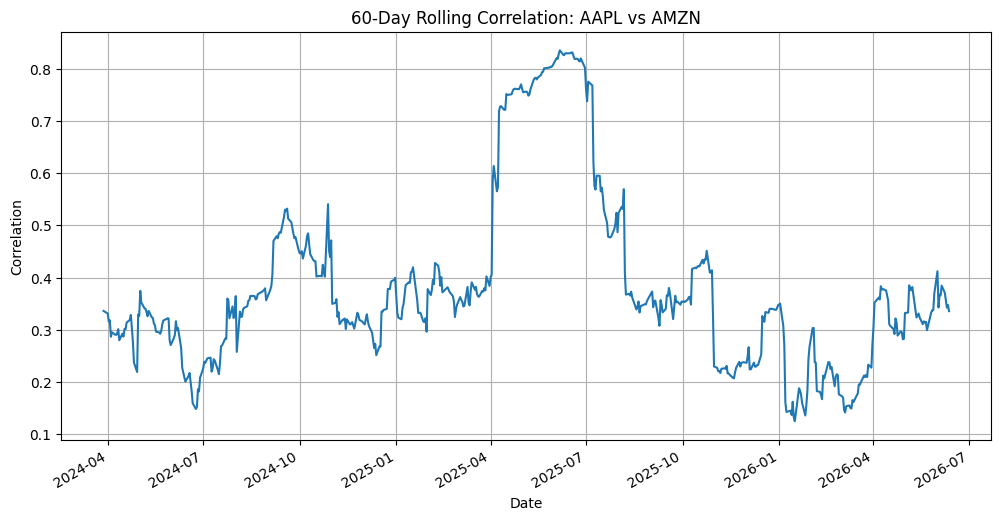

In [28]:
asset1 = "AAPL"
asset2 = "AMZN"

rolling_corr = (
    log_returns[asset1]
    .rolling(60)
    .corr(log_returns[asset2])
)

plt.figure(figsize=(12,6))
rolling_corr.plot()

plt.title(f"60-Day Rolling Correlation: {asset1} vs {asset2}")
plt.ylabel("Correlation")
plt.grid(True)

plt.show()